In [39]:
import sys
import os

# Add parent directory of the notebook to sys.path
sys.path.append(os.path.abspath(".."))

In [ ]:
import numpy as np
import pickle as pkl
from plot_params import *
from matplotlib.colors import Normalize
from matplotlib.colorbar import ColorbarBase



In [109]:
with open('MNIST_figure_plotting_data.pkl', 'rb') as f:
    results = pkl.load(f)
data_by_A = results['data_by_A']
acc_by_A = results['acc_by_A']
A_vals_sorted = results['A_vals_sorted']
total_runs = results['total_runs']
accuracy_cutoff = results['accuracy_cutoff']
r2_from_all_pc = results['r2_from_all_pc']

viridis = plt.colormaps["plasma"]
colors = [viridis(i / max(len(A_vals_sorted) - 1, 1)) for i in range(len(A_vals_sorted))]


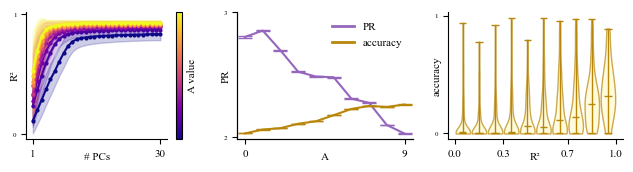

In [124]:
from matplotlib.lines import Line2D


fig, axs = plt.subplots(1, 3, figsize=(FIG_WIDTH*1.4, FIG_WIDTH*1.2/4))

ax_r2_pcs, ax_pr_ood, ax_box2 = (axs[0], axs[1], axs[2])

### R^2 vs num PCs
for idx, A_val in enumerate(A_vals_sorted):
    entries = data_by_A[A_val]
    min_len = min(len(e["r2_per_n"]) for e in entries)
    n_vals = np.array([entries[0]["r2_per_n"][i][0] for i in range(min_len)])
    r2_matrix = np.array([[r2 for _, r2 in e["r2_per_n"][:min_len]] for e in entries])
    r2_mean = r2_matrix.mean(axis=0)
    r2_std = r2_matrix.std(axis=0)
    c = colors[idx]
    ax_r2_pcs.plot(n_vals, r2_mean, label=f"A={A_val}", marker="o", markersize=2, color=c)
    ax_r2_pcs.fill_between(n_vals, r2_mean - r2_std, r2_mean + r2_std, alpha=0.2, color=c)
ax_r2_pcs.set_xlabel("# PCs", labelpad=-5)
ax_r2_pcs.set_ylabel("R²", labelpad=-5)
ax_r2_pcs.set_xticks([1, n_vals[-1]])
ax_r2_pcs.set_yticks([0, 1])
# Create a custom colormap legend for A (0 to 9)

sm = plt.cm.ScalarMappable(cmap=viridis, norm=Normalize(vmin=0, vmax=9))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax_r2_pcs, orientation='vertical')
cbar.set_label("A value")
cbar.set_ticks([])

### PR and OOD accuracy
r2_color = 'tab:purple'
acc_color = 'darkgoldenrod'
pr_by_A = [data_by_A[A_val] for A_val in A_vals_sorted]
pr_values_means = [np.mean([e["participation_ratio"] for e in entries]) for entries in pr_by_A]
pr_values_stds = [np.std([e["participation_ratio"] for e in entries])/len(entries) for entries in pr_by_A]

ax_pr_ood.errorbar(A_vals_sorted, pr_values_means, yerr=pr_values_stds, fmt='-o', c='tab:purple', capsize=5, markersize=0)
ax_pr_ood.set_yticks([np.floor(min(pr_values_means)), np.ceil(max(pr_values_means))])
ax_pr_ood.set_ylabel('PR', labelpad=-5)
ax_pr_ood.set_xticks([A_vals_sorted[0], A_vals_sorted[-1]])
ax_pr_ood.set_xlabel('A', labelpad=-5)


excluded_pairs_acc_by_A = [data_by_A[A_val] for A_val in A_vals_sorted]
excluded_pairs_acc_values = []
for entries in excluded_pairs_acc_by_A:
    vals_l = []
    for e in entries:
        if "excluded_pairs_accuracy" in e:
            vals_l.append(e["excluded_pairs_accuracy"])
    excluded_pairs_acc_values.append(vals_l)
ood_means = [np.mean(vals) for vals in excluded_pairs_acc_values]
ood_std = [np.std(vals)/len(vals) for vals in excluded_pairs_acc_values]
# ax_pr_ood.axes.spines['right'].set_visible(True)
# ax_pr_ood.spines['right'].set_color(acc_color)
ax_pr_ood2 = ax_pr_ood.twinx()
# ax_pr_ood2.spines['right'].set_color(acc_color)
# ax_pr_ood2.spines['right'].set_linewidth(2)  # Make the right axis line more visible
# ax_pr_ood2.yaxis.label.set_color(acc_color)
# ax_pr_ood2.tick_params(axis='y', colors=acc_color)
ax_pr_ood2.errorbar(A_vals_sorted, ood_means, yerr=ood_std, fmt='-o', c=acc_color, capsize=5, markersize=0)
ax_pr_ood2.set_yticks([])
# ax_pr_ood2.set_ylabel('accuracy', labelpad=-17)

custom_lines = [Line2D([0], [0], color=r2_color, lw=2),
                Line2D([0], [0], color=acc_color, lw=2)]
ax_pr_ood2.legend(custom_lines, ['PR', 'accuracy'])

# Remove empty bins for plotting
# Bin max_r2_values into bins of size 0.1

max_r2_values = [[d['r2_per_n'][0][1] for d in data] for data in data_by_A.values()]
max_r2_values = [item for sublist in max_r2_values for item in sublist]
excluded_pairs_acc_values = [[d['excluded_pairs_accuracy'] for d in data] for data in data_by_A.values()]
excluded_pairs_acc_values = [item for sublist in excluded_pairs_acc_values for item in sublist]
A_values = [[int(k) for d in v] for k, v in data_by_A.items()]
A_values = [item for sublist in A_values for item in sublist]

from scipy import stats

# Scatter plot
# Bin max_r2_values into bins of size 0.1
bin_width = 0.1
min_r2 = 0.0
max_r2 = 1.0
bins = np.arange(min_r2, max_r2 + bin_width, bin_width)
bin_centers = bins[:-1] + bin_width / 2

# Assign each entry to a bin
binned_acc = [[] for _ in range(len(bins)-1)]
for r2, acc in zip(max_r2_values, excluded_pairs_acc_values):
    for i in range(len(bins)-1):
        if bins[i] <= r2 < bins[i+1] or (i == len(bins)-2 and r2 == bins[-1]):
            binned_acc[i].append(acc)
            break

# Remove empty bins for plotting
non_empty_bins = [(i, a) for i, a in enumerate(binned_acc) if len(a) > 0]
violin_data = [a for i, a in non_empty_bins]
violin_positions = [bin_centers[i] for i, a in non_empty_bins]

ax_box2.set_yticks([0, 1])
ax_box2.set_ylabel('accuracy', labelpad=-5)
ax_box2.set_xlabel('R²', labelpad=-5)
ax_box2.set_xticks([0, 0.3, 0.7, 1])
vp = ax_box2.violinplot(
    violin_data,
    positions=violin_positions,
    widths=bin_width*0.9,
    showmeans=False, showmedians=True, showextrema=True
)
# Customize colors
for pc in vp['bodies']:
    pc.set_facecolor('lemonchiffon')
    pc.set_edgecolor('darkgoldenrod')
    pc.set_alpha(0.7)  # Set transparency
for partname in ('cbars','cmins','cmaxes','cmedians'):
    vp_part = vp[partname]
    vp_part.set_edgecolor('darkgoldenrod')
    vp_part.set_linewidth(1)


ax_pr_ood2.set_ylim(ax_box2.get_ylim())


fig.savefig(r'./final_results/figures/fig_MNIST.png', dpi=300, bbox_inches='tight')

<ErrorbarContainer object of 3 artists>

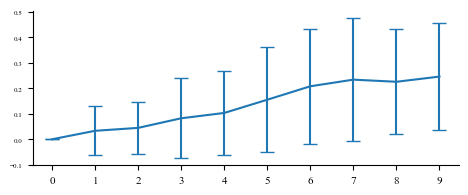

In [59]:

excluded_pairs_acc_by_A = [data_by_A[A_val] for A_val in A_vals_sorted]
excluded_pairs_acc_values = []
for entries in excluded_pairs_acc_by_A:
    vals_l = []
    for e in entries:
        if "excluded_pairs_accuracy" in e:
            vals_l.append(e["excluded_pairs_accuracy"])
    excluded_pairs_acc_values.append(vals_l)
len(excluded_pairs_acc_values)

10